Writing FIR filter coefficients to /home/brandon/git/projects/OrbitESC/src/control/gen/fir_coeffs.h


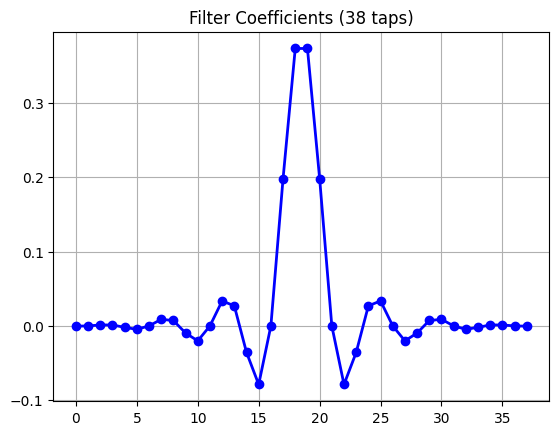

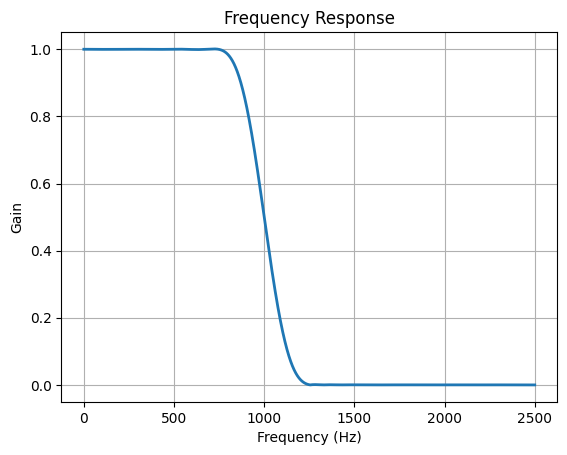

In [5]:
# Explore FIR Design
# https://scipy-cookbook.readthedocs.io/items/FIRFilter.html

import os
from numpy import pi, absolute
from scipy.signal import kaiserord, firwin, freqz
from pylab import figure, clf, plot, xlabel, ylabel, title, grid
from sk_dsp_comm import coeff2header
from pathlib import Path

# Define the filter specifications
sample_freq = 5000  # Hardware sample rate
nyq_rate = sample_freq / 2.0  # Nyquist rate
width = 500.0 / nyq_rate  # Transition band width in Hz
ripple_db = 60   # Stopband attenuation in dB
cutoff_hz = 1000  # Cutoff frequency in Hz

# Design the FIR filter
N, beta = kaiserord(ripple_db, width)
taps = firwin(N, cutoff_hz / nyq_rate, window=('kaiser', beta))
tap_str = ', '.join([f"{t:.7f}f" for t in taps])

# Write the filter coefficients to a header file
output_file = Path(os.getcwd()).resolve().parent / "src/control/gen/fir_coeffs.h"
print(f"Writing FIR filter coefficients to {output_file.as_posix()}")
coeff2header.fir_header(output_file.as_posix(), taps)

# Compute the frequency response
w, h = freqz(taps)

#------------------------------------------------
# Plot the FIR filter coefficients.
#------------------------------------------------
figure(1)
plot(taps, 'bo-', linewidth=2)
title('Filter Coefficients (%d taps)' % N)
grid(True)

#------------------------------------------------
# Plot the magnitude response of the filter.
#------------------------------------------------
figure(2)
clf()
w, h = freqz(taps, worN=8000)
plot((w/pi)*nyq_rate, absolute(h), linewidth=2)
xlabel('Frequency (Hz)')
ylabel('Gain')
title('Frequency Response')
grid(True)